<a href="https://colab.research.google.com/github/Rohanrathod7/my-ds-labs/blob/main/06_Joining_Data_with_pandas/03_Advanced_Merging_and_Concatenating.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 3. Advanced Merging and Concatenating

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import datetime as dt

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/06_Joining_Data_with_pandas/Dataset/movies.p"
# Read the CSV file
# Apply pd.to_numeric only to relevant columns, excluding 'text'
movies = pd.read_pickle(url)

# Print the head of the homelessness data
print(movies.head())

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/06_Joining_Data_with_pandas/Dataset/financials.p"
# Read the CSV file
# Apply pd.to_numeric only to relevant columns, excluding 'text'
financials = pd.read_pickle(url)

# Print the head of the homelessness data
print(financials.head())

      id                 title  popularity release_date
0    257          Oliver Twist   20.415572   2005-09-23
1  14290  Better Luck Tomorrow    3.877036   2002-01-12
2  38365             Grown Ups   38.864027   2010-06-24
3   9672              Infamous    3.680896   2006-11-16
4  12819       Alpha and Omega   12.300789   2010-09-17
       id     budget       revenue
0   19995  237000000  2.787965e+09
1     285  300000000  9.610000e+08
2  206647  245000000  8.806746e+08
3   49026  250000000  1.084939e+09
4   49529  260000000  2.841391e+08


----

### Filtering joins

**Steps of a semi join**  
In the last video, you were shown how to perform a semi join with pandas. In this exercise, you'll solidify your understanding of the necessary steps. Recall that a semi join filters the left table to only the rows where a match exists in both the left and right tables.

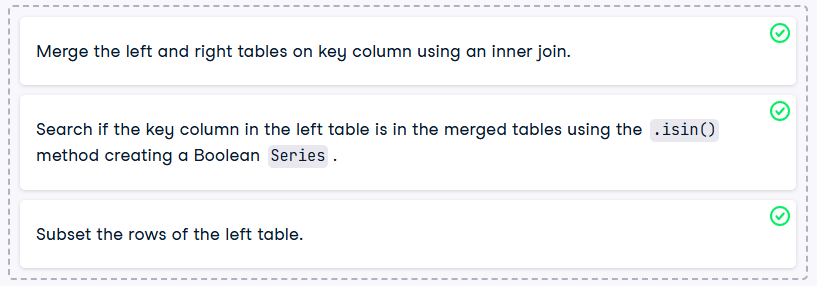

 You have a sense of the steps in this technique. It first merges the tables, then searches it for which rows belong in the final result creating a filter and subsets the left table with that filter.

**Performing an anti join**
In our music streaming company dataset, each customer is assigned an employee representative to assist them. In this exercise, filter the employee table by a table of top customers, returning only those employees who are not assigned to a customer. The results should resemble the results of an anti join. The company's leadership will assign these employees additional training so that they can work with high valued customers.

The top_cust and employees tables have been provided for you.

In [4]:
url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/06_Joining_Data_with_pandas/Dataset/employees.csv"
# Read the CSV file
# Apply pd.to_numeric only to relevant columns, excluding 'text'
employees = pd.read_csv(url)

# Print the head of the homelessness data
print(employees.head())

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/06_Joining_Data_with_pandas/Dataset/top_cust.csv"
# Read the CSV file
# Apply pd.to_numeric only to relevant columns, excluding 'text'
top_cust = pd.read_csv(url)

# Print the head of the homelessness data
print(top_cust.head())

   srid    lname     fname                title   hire_date  \
0     1    Adams    Andrew      General Manager  2002-08-14   
1     2  Edwards     Nancy        Sales Manager  2002-05-01   
2     3  Peacock      Jane  Sales Support Agent  2002-04-01   
3     4     Park  Margaret  Sales Support Agent  2003-05-03   
4     5  Johnson     Steve  Sales Support Agent  2003-10-17   

                      email  
0    andrew@chinookcorp.com  
1     nancy@chinookcorp.com  
2      jane@chinookcorp.com  
3  margaret@chinookcorp.com  
4     steve@chinookcorp.com  
   cid  srid      fname        lname               phone                 fax  \
0    1     3       Luís    Gonçalves  +55 (12) 3923-5555  +55 (12) 3923-5566   
1    2     5     Leonie       Köhler    +49 0711 2842222                 NaN   
2    3     3   François     Tremblay   +1 (514) 721-4711                 NaN   
3    4     4      Bjørn       Hansen     +47 22 44 22 22                 NaN   
4    5     4  František  Wichterlová    +

In [5]:
# Merge employees and top_cust
empl_cust = employees.merge(top_cust, on='srid',
                                 how='left', indicator=True)

# Select the srid column where _merge is left_only
srid_list = empl_cust.loc[empl_cust['_merge'] == 'left_only', 'srid']

# Get employees not working with top customers
print(employees[employees["srid"].isin(srid_list)])

# You performed an anti join by first merging the tables with a left join, selecting the ID of those employees who did not support a top customer,
# and then subsetting the original employee's table. From that, we can see that there are five employees not supporting top customers.
# Anti joins are a powerful tool to filter a main table (i.e. employees) by another (i.e. customers).

   srid     lname    fname            title   hire_date  \
0     1     Adams   Andrew  General Manager  2002-08-14   
1     2   Edwards    Nancy    Sales Manager  2002-05-01   
5     6  Mitchell  Michael       IT Manager  2003-10-17   
6     7      King   Robert         IT Staff  2004-01-02   
7     8  Callahan    Laura         IT Staff  2004-03-04   

                     email  
0   andrew@chinookcorp.com  
1    nancy@chinookcorp.com  
5  michael@chinookcorp.com  
6   robert@chinookcorp.com  
7    laura@chinookcorp.com  


**Performing a semi join**  
Some of the tracks that have generated the most significant amount of revenue are from TV-shows or are other non-musical audio. You have been given a table of invoices that include top revenue-generating items. Additionally, you have a table of non-musical tracks from the streaming service. In this exercise, you'll use a semi join to find the top revenue-generating non-musical tracks.

The tables non_mus_tcks, top_invoices, and genres have been loaded for you.

In [24]:
url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/06_Joining_Data_with_pandas/Dataset/top_invoices.csv"
# Read the CSV file
# Apply pd.to_numeric only to relevant columns, excluding 'text'
top_invoices = pd.read_csv(url)

# Print the head of the homelessness data
print(top_invoices.head())

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/06_Joining_Data_with_pandas/Dataset/non_mus_tcks.csv"
# Read the CSV file
# Apply pd.to_numeric only to relevant columns, excluding 'text'

non_mus_tcks = pd.read_csv(url)

# Print the head of the non_mus_tcks data if successfully loaded
print(non_mus_tcks.head())

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/06_Joining_Data_with_pandas/Dataset/genres.csv"
# Read the CSV file
# Apply pd.to_numeric only to relevant columns, excluding 'text'

genres = pd.read_csv(url)

# Print the head of the non_mus_tcks data if successfully loaded
print(genres.head())

   ilid  iid   tid  uprice  quantity
0   470   88  2832    1.99         1
1   473   88  2850    1.99         1
2   476   88  2868    1.99         1
3   527   96  3214    1.99         1
4   528   96  3223    1.99         1
    tid                    name  aid  mtid  gid  u_price
0  2820  Occupation / Precipice  227     3   19     1.99
1  2821           Exodus, Pt. 1  227     3   19     1.99
2  2822           Exodus, Pt. 2  227     3   19     1.99
3  2823           Collaborators  227     3   19     1.99
4  2824                    Torn  227     3   19     1.99
   gid                name
0    1                Rock
1    2                Jazz
2    3               Metal
3    4  Alternative & Punk
4    5       Rock And Roll


In [25]:
# Merge the non_mus_tcks and top_invoices tables on tid
tracks_invoices = non_mus_tcks.merge(top_invoices, on="tid")

# Use .isin() to subset non_mus_tcks to rows with tid in tracks_invoices
top_tracks = non_mus_tcks[non_mus_tcks['tid'].isin(tracks_invoices["tid"])]

# Group the top_tracks by gid and count the tid rows
cnt_by_gid = top_tracks.groupby(['gid'], as_index=False).agg({'tid':"count"})

# Merge the genres table to cnt_by_gid on gid and print
print(cnt_by_gid.merge(genres, on="gid").head())


# you replicated a semi join to filter the table of tracks by the table of invoice items to find the top revenue non-musical tracks.
# With some additional data manipulation, you discovered that _'TV-shows'_ is the non-musical genre that has the most top revenue-generating tracks.
# Now that you've done both semi- and anti joins, it's time to move to the next topic.

   gid  tid      name
0   19    4  TV Shows
1   21    2     Drama
2   22    1    Comedy


----

### Concatenate DataFrames together vertically

**Concatenation basics**  
You have been given a few tables of data with musical track info for different albums from the metal band, Metallica. The track info comes from their Ride The Lightning, Master Of Puppets, and St. Anger albums. Try various features of the .concat() method by concatenating the tables vertically together in different ways.

The tables `tracks_master`, `tracks_ride`, and `tracks_st` have loaded for you.

In [26]:
url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/06_Joining_Data_with_pandas/Dataset/tracks_master.csv"
# Read the CSV file
# Apply pd.to_numeric only to relevant columns, excluding 'text'
tracks_master = pd.read_csv(url)

# Print the head of the homelessness data
print(tracks_master.head())

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/06_Joining_Data_with_pandas/Dataset/tracks_ride.csv"
# Read the CSV file
# Apply pd.to_numeric only to relevant columns, excluding 'text'

tracks_ride = pd.read_csv(url)

# Print the head of the non_mus_tcks data if successfully loaded
print(tracks_ride.head())

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/06_Joining_Data_with_pandas/Dataset/tracks_st.csv"
# Read the CSV file
# Apply pd.to_numeric only to relevant columns, excluding 'text'

tracks_st = pd.read_csv(url)

# Print the head of the non_mus_tcks data if successfully loaded
print(tracks_st.head())

    tid               name  aid  mtid  gid             composer  u_price
0  1853            Battery  152     1    3  J.Hetfield/L.Ulrich     0.99
1  1854  Master Of Puppets  152     1    3            K.Hammett     0.99
2  1857  Disposable Heroes  152     1    3  J.Hetfield/L.Ulrich     0.99
    tid                     name  aid  mtid  gid  u_price
0  1874     Fight Fire With Fire  154     1    3     0.99
1  1875       Ride The Lightning  154     1    3     0.99
2  1876  For Whom The Bell Tolls  154     1    3     0.99
3  1877            Fade To Black  154     1    3     0.99
4  1878        Trapped Under Ice  154     1    3     0.99
    tid                  name  aid  mtid  gid  u_price
0  1882               Frantic  155     1    3     0.99
1  1883             St. Anger  155     1    3     0.99
2  1884  Some Kind Of Monster  155     1    3     0.99
3  1885          Dirty Window  155     1    3     0.99
4  1886         Invisible Kid  155     1    3     0.99


In [27]:
# Concatenate the tracks
tracks_from_albums = pd.concat([tracks_master, tracks_ride, tracks_st],
                               sort=True)
print(tracks_from_albums)

   aid             composer  gid  mtid                     name   tid  u_price
0  152  J.Hetfield/L.Ulrich    3     1                  Battery  1853     0.99
1  152            K.Hammett    3     1        Master Of Puppets  1854     0.99
2  152  J.Hetfield/L.Ulrich    3     1        Disposable Heroes  1857     0.99
0  154                  NaN    3     1     Fight Fire With Fire  1874     0.99
1  154                  NaN    3     1       Ride The Lightning  1875     0.99
2  154                  NaN    3     1  For Whom The Bell Tolls  1876     0.99
3  154                  NaN    3     1            Fade To Black  1877     0.99
4  154                  NaN    3     1        Trapped Under Ice  1878     0.99
0  155                  NaN    3     1                  Frantic  1882     0.99
1  155                  NaN    3     1                St. Anger  1883     0.99
2  155                  NaN    3     1     Some Kind Of Monster  1884     0.99
3  155                  NaN    3     1             D

In [28]:
# Concatenate the tracks so the index goes from 0 to n-1
tracks_from_albums = pd.concat([tracks_master, tracks_ride, tracks_st],
                               ignore_index=True,
                               sort=True)
print(tracks_from_albums)

    aid             composer  gid  mtid                     name   tid  \
0   152  J.Hetfield/L.Ulrich    3     1                  Battery  1853   
1   152            K.Hammett    3     1        Master Of Puppets  1854   
2   152  J.Hetfield/L.Ulrich    3     1        Disposable Heroes  1857   
3   154                  NaN    3     1     Fight Fire With Fire  1874   
4   154                  NaN    3     1       Ride The Lightning  1875   
5   154                  NaN    3     1  For Whom The Bell Tolls  1876   
6   154                  NaN    3     1            Fade To Black  1877   
7   154                  NaN    3     1        Trapped Under Ice  1878   
8   155                  NaN    3     1                  Frantic  1882   
9   155                  NaN    3     1                St. Anger  1883   
10  155                  NaN    3     1     Some Kind Of Monster  1884   
11  155                  NaN    3     1             Dirty Window  1885   
12  155                  NaN    3     

In [29]:
# Concatenate the tracks, show only columns names that are in all tables
tracks_from_albums = pd.concat([tracks_master, tracks_ride, tracks_st],
                               join='inner',
                               sort=True)
print(tracks_from_albums)

# You've concatenated your first set of tables, adjusted the index, and altered the columns shown in the output.
# The .concat() method is a very flexible tool that is useful for combining data into a new dataset.

   aid  gid  mtid                     name   tid  u_price
0  152    3     1                  Battery  1853     0.99
1  152    3     1        Master Of Puppets  1854     0.99
2  152    3     1        Disposable Heroes  1857     0.99
0  154    3     1     Fight Fire With Fire  1874     0.99
1  154    3     1       Ride The Lightning  1875     0.99
2  154    3     1  For Whom The Bell Tolls  1876     0.99
3  154    3     1            Fade To Black  1877     0.99
4  154    3     1        Trapped Under Ice  1878     0.99
0  155    3     1                  Frantic  1882     0.99
1  155    3     1                St. Anger  1883     0.99
2  155    3     1     Some Kind Of Monster  1884     0.99
3  155    3     1             Dirty Window  1885     0.99
4  155    3     1            Invisible Kid  1886     0.99


 **Concatenating with keys**  
The leadership of the music streaming company has come to you and asked you for assistance in analyzing sales for a recent business quarter. They would like to know which month in the quarter saw the highest average invoice total. You have been given three tables with invoice data named inv_jul, inv_aug, and inv_sep. Concatenate these tables into one to create a graph of the average monthly invoice total.

In [31]:
url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/06_Joining_Data_with_pandas/Dataset/inv_jul.csv"
# Read the CSV file
# Apply pd.to_numeric only to relevant columns, excluding 'text'
inv_jul = pd.read_csv(url)

# Print the head of the homelessness data
print(inv_jul.head())

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/06_Joining_Data_with_pandas/Dataset/inv_aug.csv"
# Read the CSV file
# Apply pd.to_numeric only to relevant columns, excluding 'text'

inv_aug = pd.read_csv(url)

# Print the head of the non_mus_tcks data if successfully loaded
print(inv_aug.head())

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/06_Joining_Data_with_pandas/Dataset/inv_sep.csv"
# Read the CSV file
# Apply pd.to_numeric only to relevant columns, excluding 'text'

inv_sep = pd.read_csv(url)

# Print the head of the non_mus_tcks data if successfully loaded
print(inv_sep.head())

   iid  cid invoice_date  total       bill_ctry
0   42   51   2009-07-06   1.98          Sweden
1   43   53   2009-07-06   1.98              UK
2   44   55   2009-07-07   3.96       Australia
3   45   59   2009-07-08   5.94           India
4   46    6   2009-07-11   8.91  Czech Republic
   iid  cid invoice_date  total bill_ctry
0   49   30   2009-08-06   1.98    Canada
1   50   32   2009-08-06   1.98    Canada
2   51   34   2009-08-07   3.96  Portugal
3   52   38   2009-08-08   5.94   Germany
4   53   44   2009-08-11   8.91   Finland
   iid  cid invoice_date  total bill_ctry
0   56    9   2009-09-06   1.98   Denmark
1   57   11   2009-09-06   1.98    Brazil
2   58   13   2009-09-07   3.96    Brazil
3   59   17   2009-09-08   5.94       USA
4   60   23   2009-09-11   8.91       USA


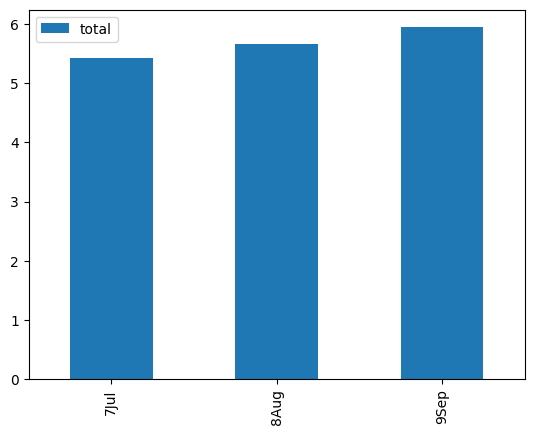

In [32]:
# Concatenate the tables and add keys
inv_jul_thr_sep = pd.concat([inv_jul, inv_aug, inv_sep],
                            keys=["7Jul", "8Aug", "9Sep"])

# Group the invoices by the index keys and find avg of the total column
avg_inv_by_month = inv_jul_thr_sep.groupby(level=0).agg({'total':'mean'})

# Bar plot of avg_inv_by_month
avg_inv_by_month.plot(kind="bar")
plt.show()

# There are many ways to write code for this task. However, concatenating the tables with a key provides a hierarchical index that can be used for grouping.
# Once grouped, you can average the groups and create plots. You were able to find out that September had the highest average invoice total.

-----

### Verifying integrity

**Validating a merge**  
You have been given 2 tables, artists, and albums. Merge them using artists.merge(albums, on='artid').head(), adjusting the validate argument to determine which statement is False.

    -> You can use 'many_to_one' without an error, since there is a duplicate key in the left table.

    This statement is false. There is a duplicate value in the artid column in the albums table, which is the right table in this merge. Therefore, setting validate equal to 'many_to_one' or 'one_to_one' will raise an error, making this statement false.

**Concatenate and merge to find common songs**  
The senior leadership of the streaming service is requesting your help again. You are given the historical files for a popular playlist in the classical music genre in 2018 and 2019. Additionally, you are given a similar set of files for the most popular pop music genre playlist on the streaming service in 2018 and 2019. Your goal is to concatenate the respective files to make a large classical playlist table and overall popular music table. Then filter the classical music table using a semi join to return only the most popular classical music tracks.

The tables classic_18, classic_19, and pop_18, pop_19 have been loaded for you. Additionally, pandas has been loaded as pd.

In [33]:
url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/06_Joining_Data_with_pandas/Dataset/classic_18.csv"
# Read the CSV file
# Apply pd.to_numeric only to relevant columns, excluding 'text'
classic_18 = pd.read_csv(url)

# Print the head of the homelessness data
print(classic_18.head())

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/06_Joining_Data_with_pandas/Dataset/classic_19.csv"
# Read the CSV file
# Apply pd.to_numeric only to relevant columns, excluding 'text'

classic_19 = pd.read_csv(url)

# Print the head of the non_mus_tcks data if successfully loaded
print(classic_19.head())

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/06_Joining_Data_with_pandas/Dataset/pop_18.csv"
# Read the CSV file
# Apply pd.to_numeric only to relevant columns, excluding 'text'

pop_18 = pd.read_csv(url)

# Print the head of the non_mus_tcks data if successfully loaded
print(pop_18.head())

url = "https://raw.githubusercontent.com/Rohanrathod7/my-ds-labs/main/06_Joining_Data_with_pandas/Dataset/pop_19.csv"
# Read the CSV file
# Apply pd.to_numeric only to relevant columns, excluding 'text'

pop_19 = pd.read_csv(url)

# Print the head of the non_mus_tcks data if successfully loaded
print(pop_19.head())

   pid   tid
0   12  3483
1   12  3416
2   12  3489
3   12  3479
4   12  3440
   pid   tid
0   12  3482
1   12  3434
2   12  3448
3   12  3499
4   12  3425
   pid   tid
0    1  3063
1    1  2712
2    1  2641
3    1  2271
4    1   919
   pid   tid
0    1  2115
1    1   297
2    1   272
3    1  3023
4    1  1193


In [34]:
# Concatenate the classic tables vertically
classic_18_19 = pd.concat([classic_18, classic_19], ignore_index=True)

# Concatenate the pop tables vertically
pop_18_19 = pd.concat([pop_18, pop_19], ignore_index=True)

# Merge classic_18_19 with pop_18_19
classic_pop = classic_18_19.merge(pop_18_19, on="tid")

# Using .isin(), filter classic_18_19 rows where tid is in classic_pop
popular_classic = classic_18_19[classic_18_19["tid"].isin(classic_pop["tid"])]

# Print popular chart
print(popular_classic)

# you demonstrated many of the concepts discussed in this chapter, including concatenation,
# and semi joins. You now have experience combining data vertically and using semi- and anti joins

    pid   tid
3    12  3479
10   12  3439
21   12  3445
23   12  3449
48   12  3437
50   12  3435
